# CAIM Lab Session 5: Duplicate detection using simhash

In this session you will:

- implement the simhashing algorithm
- apply it to the `arxiv` abstracts to detect near duplicates among documents in this index

## 1. Simhash-based near-duplicate detection algorithm

We depart from an indexed corpus, namely the one that we have used in previous sessions that contains 58102 abstracts from the
scientific [arXiv.org](https://arxiv.org) repository. The following pseudocode uses $k,m$ as the usual parameters for lsh (locality sensitive hashing)
scheme for gap amplification (repetition of $m$ lsh tables, using $k$ projections each).

  1. For each word $t$ in the vocabulary $V$ we generate $b = k\times m$ random $\pm 1$ signs:
      - generate a unique hash (bitstring) $h_t$ of size $b$
      - let $h'_t$ be the hash above but replacing each 0 with -1.
  
  2. We view each document as a tf-idf weighted sum of its terms. Thus, to hash a document, we sum the weighted contributions of all its terms. Specifically, for each document in our corpus represented by list of non-zero entries $t, w_t$:
      - compute $simhash(d)$ as sum $\sum_t h'_t * w_t$. 
      - convert $simhash(d)$ to bit vector using the sign of entries (positive entries become 1, negative ones become 0)
  
  3. Slice simhashes into $m$ chunks of $k$ bits
     - for each $k$-bit chunk:
        - place the document into the bucket given by the chunk in the appropriate table. Note that we may identify each chunk with an integer index between 0 and 2^k - 1.
  
  4. Similar documents will likely fall on the same side of many hyperplanes, and thus share one or more $k$-bit chunks. Thus, the potential duplicates are pairs of documents that fall into the same bucket in **at least one** hash table. Now we need to
     - compute cosine similarity among these potential duplicates, and
     - show pairs in decreasing cosine similarity order.


---

**Exercise 1:**  

As a little exercise, suppose that a document $d$ contains _two_ non-zero entries, which correspond to terms `bit` with tf-idf weight $0.4$ and `coin` with tf-idf weight $1.2$.
The md5 hash code for `bit` is 1111 and the md5 code for `coin` is 1001 (so $b=4$). Compute the binary simhash for this document with $k=4, m = 1$. (_Hint: result should be 1001_)

---


bit -> 1 1 1 1 -> 1  1  1 1 -> 0.4  0.4  0.4  0.4  
coin-> 1 0 0 1 -> 1 -1 -1 1 -> 1.2 -1.2 -1.2  1.2  
                   es sumen -> 1.6 -0.8 -0.8  1.6  -> 1 0 0 1  

## 2. Hashing codes for terms in vocabulary

To make your life easier, we provide code for generating hash codes for the terms in the vocabulary.
The given function takes as input the size of the hash, as well as the term itself.

We use a fast deterministic hash (MD5) to get repeatable pseudo-random bits. Even though it is actually deterministic, we assume that in practice its output behaviour is sufficiently similar to that of a truly random hash function.

In [1]:
import hashlib

def _termhash(x : str, b : int) -> str:
    """returns bitstring of size b based on md5 algorithm"""
    assert b <= 128, 'this encoding scheme supports hashes of length at most 128; try smaller b'
    h = hashlib.md5(x.encode('utf8')).digest()
    return ''.join(format(byte, '08b') for byte in h)[:b]

for w in ['bit', 'coin', 'hola que tal', 'metancetamina', 'alcohol', 'nicotina', 'ron']:
    print(f'hash.md5({w}) = {_termhash(w, 4)}')



hash.md5(bit) = 1111
hash.md5(coin) = 1001
hash.md5(hola que tal) = 0110
hash.md5(metancetamina) = 1101
hash.md5(alcohol) = 1011
hash.md5(nicotina) = 0101
hash.md5(ron) = 0100


## 3. Loading tf-idf for the whole corpus

We provide the document-term matrix with normalized tf-idf weights with a sparse representation.
This is so that further code does not need to check for tf-idf weights against elasticsearch which is very slow.

Please download the corpus data from https://www.cs.upc.edu/~caim/05corpus.pkl and run the following cells to access the data.

In [2]:
import pickle
import os

fname = '05corpus.pkl'

with open(fname, 'rb') as f:
    corpus = pickle.load(f)

### have a look at the data

Loaded corpus with 58102 documents.
A few document ids are: ['1410', '17489', '21051', '21156', '3253', '36233', '37822', '46504', '48433', '57080']
Each document is a dictionary with term -> tf-idf weights, e.g. the first:
{'0.009': np.float64(0.07755241277245155), '0.03': np.float64(0.05390282783916337), '2.3': np.float64(0.05697594345388175), '3': np.float64(0.037520471487291714), '6': np.float64(0.06263176984143355), '8': np.float64(0.03381614985233684), 'aboard': np.float64(0.07470497254146928), 'abridged': np.float64(0.04658961411040711), 'absence': np.float64(0.04085137050637872), 'accretion': np.float64(0.07414988654879776), 'acquire': np.float64(0.05537897824225455), 'also': np.float64(0.009403647100788688), 'area': np.float64(0.03366260253470469), 'assembled': np.float64(0.05973338041851722), 'balmer': np.float64(0.06406254101592618), 'based': np.float64(0.011164937538935934), 'because': np.float64(0.027935714599668877), 'below': np.float64(0.03351983591805465), 'beta': np.fl

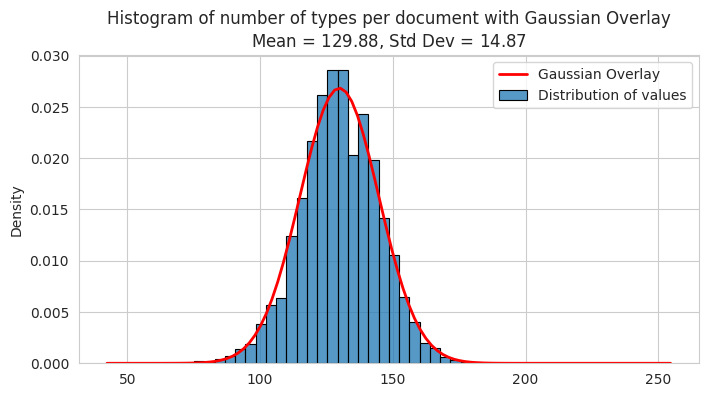

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np
import random

# show contents

print(f"Loaded corpus with {len(corpus)} documents.")
all_document_ids = list(corpus.keys())
print(f"A few document ids are: {sorted(random.sample(all_document_ids, 10))}")
print(f"Each document is a dictionary with term -> tf-idf weights, e.g. the first:")
print(corpus[all_document_ids[0]])

# obtain histogram with nr of terms in each document
values = [len(corpus[id]) for id in all_document_ids]
mu = np.mean(values)
sigma = np.std(values)
plt.figure(figsize=(8, 4))
sns.set_style("whitegrid")
sns.histplot(values, bins=50, edgecolor='black', stat='density', label='Distribution of values')
plt.title(f'Histogram of number of types per document with Gaussian Overlay\nMean = ${mu:.2f}$, Std Dev = ${sigma:.2f}$', fontsize=12)
xmin, xmax = plt.xlim()
x_axis = np.linspace(xmin, xmax, 100)

# Calculate the probability density function (PDF) for the x-values.
plt.plot(x_axis, norm.pdf(x_axis, mu, sigma), 'red', linewidth=2, label='Gaussian Overlay')
plt.legend(); # Display the labels

## 4. Simhashing scheme and near-duplicate collection and verification

---

**Exercise 2:**  

Write the `simhash` function provided below. Make sure you understand that each bit of the simhash encodes which "side" the tf-idf document representation falls on a (pseudo-)random projection. 


---


In [4]:
from tqdm import tqdm

## constants
K = 18
M = 3
B = M*K

def _simhash(id, b):
    """
        id is the document id, b is the desired length of the simhash
        it should return a bitstring of length b as explained in the
        first section of the notebook
    """
    doc=corpus[id]
    v = np.zeros(b)
    for t, w in doc.items():
        aux = _termhash(t,b)
        aux = np.array([-1 if x == '0' else 1 for x in aux])
        v += aux * w    
    
    return ''.join(['0' if x < 0 else '1' for x in v])

## simhash stores all simhashes of the whole corpus in a dictionary
simhash = {id: _simhash(id, B) for id in tqdm(corpus)}

100%|██████████| 58102/58102 [01:28<00:00, 653.34it/s]


---

**Exercise 3:**  

Based on simhashes, write code that places the documents in their corresponding lsh hash tables' buckets across $m$ repetitions. Once, the lsh hash tables have been
populated, find all potential near-duplicate candidate pairs. Check among all candidates their real cosine similarity and based on this determine true positives
(pairs of documents that are indeed similar and have collided in some table), and false positives (pairs of documents that are not similar but have collided in some table).
Compute speed of the method vs. false positives / true positives for different values of $m$ and $k$. Make sure that $k$ is not tiny (say greater than 10) if you want
the method to be fast.

---

In [5]:
def construir_lsh_tables(simhash, M=3, K=18):
    '''
    Funció per construir les taules LSH
    simhash: diccionar amb el simhash de cada document
    M: nombre de taules
    K: nombre de bits per taula
    '''

    taules = [dict() for _ in range(M)]
    for doc_id, sh in simhash.items():
        for i in range(M):
            start = i * K
            end = (i + 1) * K
            term = sh[start:end]
            id = int(term, 2)   # Pasem a enter per indexar ja que es mes eficient 
            if id not in taules[i]:
                taules[i][id] = []

            taules[i][id].append(doc_id)

    return taules

taules = construir_lsh_tables(simhash)

In [6]:
def trobar_candidats(taules):
    '''
    Funció per trobar tots els potencials near-duplicate candidate pairs
    '''
    pairs_candidates = set()
    for taula in taules:
        for _, docs in taula.items():
            if len(docs) > 1:  # Si hi ha més d'un document, escrivim totes les combinacions de parelles
                for i in range(len(docs)):
                    for j in range(i + 1, len(docs)):
                        pair = tuple(sorted([docs[i], docs[j]]))
                        pairs_candidates.add(pair)
    
    return pairs_candidates

candidats = trobar_candidats(taules)
    

In [7]:
def cosine_similarity(doc1, doc2):
    ''' 
    Calcula la similitud de cosinus entre dos documents
    '''
    tfidf1 = corpus[doc1]
    tfidf2 = corpus[doc2]

    norm1 = np.sqrt(sum(val**2 for val in tfidf1.values()))
    norm2 = np.sqrt(sum(val**2 for val in tfidf2.values()))

    if norm1 == 0 or norm2 == 0:
        return 0.0

    termes_comuns = set(tfidf1.keys()) & set(tfidf2.keys())
    producte_escalar = sum(tfidf1[term] * tfidf2[term] for term in termes_comuns)
    return producte_escalar / (norm1 * norm2)

In [8]:
def check_cosine_similarity(candidats, threshold=0.8):
    '''
    Funció per calcular la similitud de cosinus de tots els candidats
    '''
    #similituts = []
    TP = 0
    FP = 0

    for doc1, doc2 in candidats:
        cos = cosine_similarity(doc1, doc2)
        if cos >= threshold:
            TP += 1
        else:
            FP += 1
    #    sim = cosine_similarity(doc1, doc2)
    ##    similituts.append((doc1, doc2, sim))

    return TP, FP

In [9]:
TP, FP = check_cosine_similarity(candidats, threshold=0.8)
print(f"True Positives: {TP}, False Positives: {FP}")

True Positives: 16244, False Positives: 24032


In [10]:
import time

def try_values(simhash, M, K):
    '''
    Funció per trobar els fals postius i certs positius segons el valor de M i K
    simhash: diccionari amb els simhashes
    M: nombre de taules
    K: nombre de bits per taula
    '''
    
    start_time = time.time()
    taules = construir_lsh_tables(simhash, M, K)
    candidats = trobar_candidats(taules)
    TP, FP = check_cosine_similarity(candidats)
    elapsed_time = time.time() - start_time

    return TP, FP, elapsed_time


In [11]:

K_values = [13, 16, 19, 22]
M_values = [2, 3, 4, 5]

B = max(M_values) * max(K_values)
simhash = {id: _simhash(id, B) for id in tqdm(corpus)}

results = []
for K in K_values:
    for M in M_values:
        TP, FP, elapsed_time = try_values(simhash, M, K)
        results.append((M, K, TP, FP, elapsed_time))
        print(f"M={M}, K={K} => TP: {TP}, FP: {FP}, Time: {elapsed_time:.2f} seconds")

100%|██████████| 58102/58102 [02:01<00:00, 478.29it/s]



M=2, K=13 => TP: 16622, FP: 459624, Time: 27.03 seconds
M=3, K=13 => TP: 17578, FP: 699054, Time: 41.04 seconds
M=4, K=13 => TP: 18306, FP: 953134, Time: 55.33 seconds
M=5, K=13 => TP: 18680, FP: 1171500, Time: 68.33 seconds
M=2, K=16 => TP: 15729, FP: 59634, Time: 4.65 seconds
M=3, K=16 => TP: 16685, FP: 92846, Time: 6.62 seconds
M=4, K=16 => TP: 17311, FP: 121694, Time: 8.57 seconds
M=5, K=16 => TP: 17716, FP: 150361, Time: 10.28 seconds
M=2, K=19 => TP: 15192, FP: 7738, Time: 1.76 seconds
M=3, K=19 => TP: 16103, FP: 11994, Time: 2.13 seconds
M=4, K=19 => TP: 16649, FP: 15682, Time: 2.55 seconds
M=5, K=19 => TP: 17213, FP: 19508, Time: 2.88 seconds
M=2, K=22 => TP: 14638, FP: 1057, Time: 1.45 seconds
M=3, K=22 => TP: 15492, FP: 1546, Time: 1.52 seconds
M=4, K=22 => TP: 16010, FP: 2031, Time: 1.77 seconds
M=5, K=22 => TP: 16431, FP: 2641, Time: 1.92 seconds


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results, columns=['M', 'K', 'TP', 'FP', 'Temps (s)'])

df['Total Candidats'] = df['TP'] + df['FP']
df['Precisió'] = df['TP'] / df['Total Candidats']
df['Recall Estimat'] = df['TP'] / df['TP'].max()
df['F1'] = 2 * df['Precisió'] * df['Recall Estimat'] / (df['Precisió'] + df['Recall Estimat'])

print(df.to_string(index=False))


 M  K    TP      FP  Temps (s)  Total Candidats  Precisió  Recall Estimat       F1
 2 13 16622  459624  27.031610           476246  0.034902        0.889829 0.067170
 3 13 17578  699054  41.036603           716632  0.024529        0.941006 0.047811
 4 13 18306  953134  55.325150           971440  0.018844        0.979979 0.036977
 5 13 18680 1171500  68.328273          1190180  0.015695        1.000000 0.030905
 2 16 15729   59634   4.652221            75363  0.208710        0.842024 0.334507
 3 16 16685   92846   6.623777           109531  0.152331        0.893201 0.260274
 4 16 17311  121694   8.572765           139005  0.124535        0.926713 0.219564
 5 16 17716  150361  10.276837           168077  0.105404        0.948394 0.189722
 2 19 15192    7738   1.760763            22930  0.662538        0.813276 0.730209
 3 19 16103   11994   2.130578            28097  0.573122        0.862045 0.688501
 4 19 16649   15682   2.546636            32331  0.514955        0.891274 0.652761
 5 1

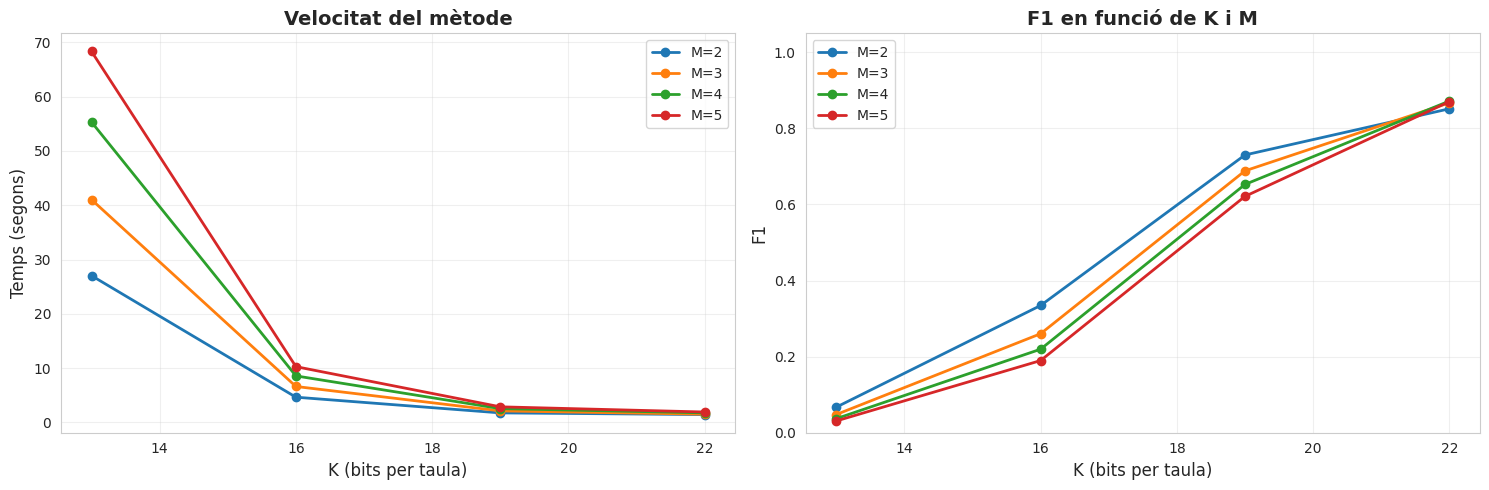

In [24]:
# Gràfic 1: Temps d'execució
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for M in M_values:
    data = df[df['M'] == M]
    plt.plot(data['K'], data['Temps (s)'], marker='o', label=f'M={M}', linewidth=2)
plt.xlabel('K (bits per taula)', fontsize=12)
plt.ylabel('Temps (segons)', fontsize=12)
plt.title('Velocitat del mètode', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Gràfic 2: F1 vs K per M
plt.subplot(1, 2, 2)
for M in M_values:
    data = df[df['M'] == M].sort_values('K')
    plt.plot(data['K'], data['F1'], marker='o', label=f'M={M}', linewidth=2)

plt.xlabel('K (bits per taula)', fontsize=12)
plt.ylabel('F1', fontsize=12)
plt.title('F1 en funció de K i M', fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

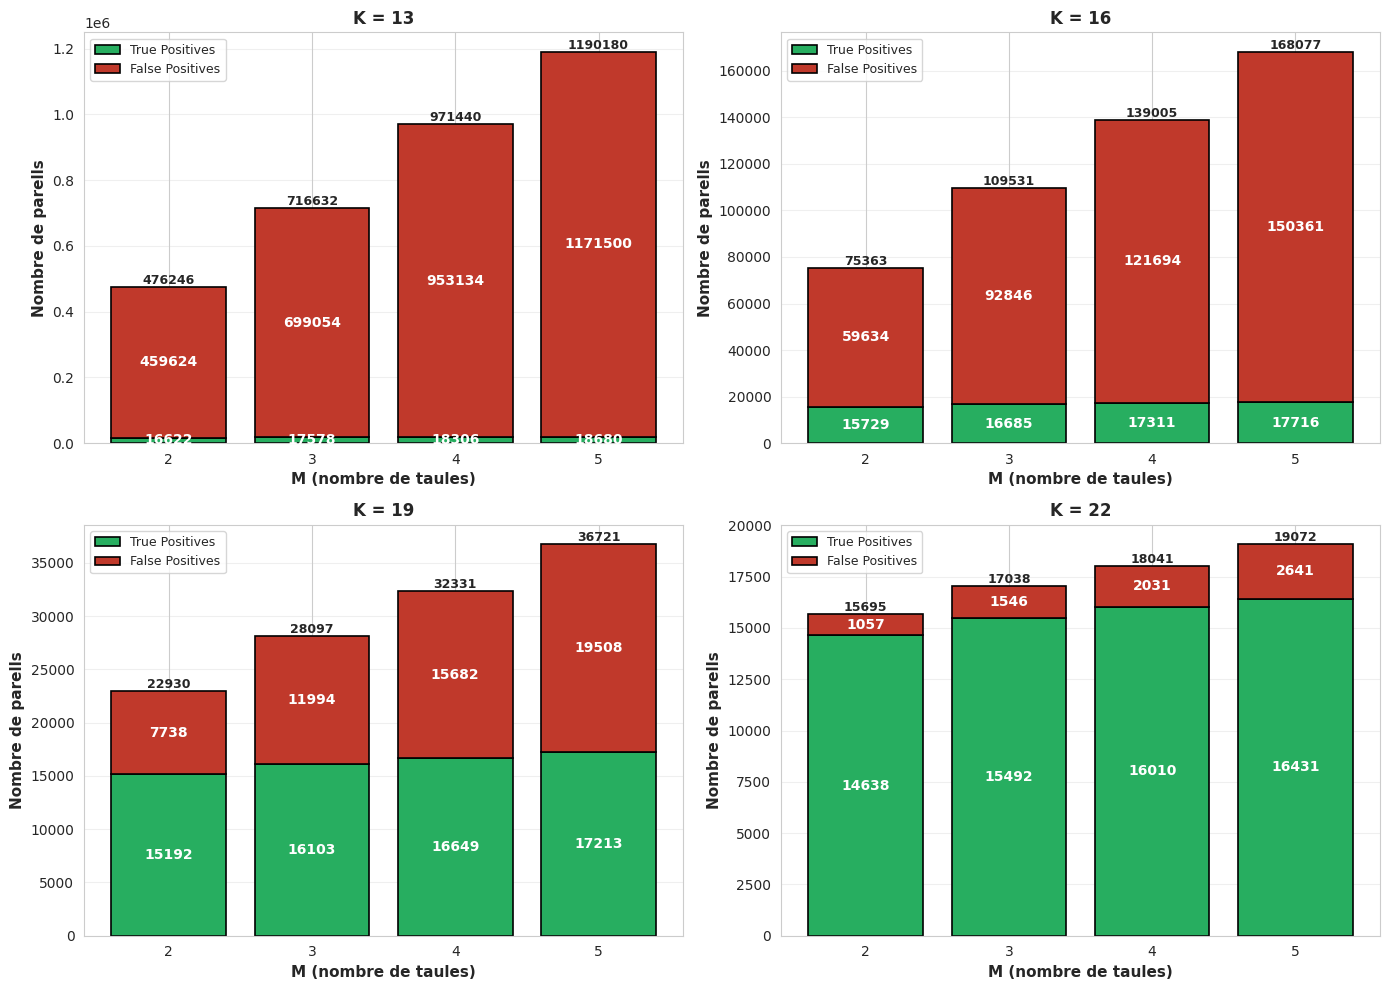

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, K in enumerate(K_values):
    ax = axes[idx]
    data_k = df[df['K'] == K]
    
    x = np.arange(len(M_values))
    
    tp_vals = data_k['TP'].values
    fp_vals = data_k['FP'].values
    
    # Barres apilades
    bars1 = ax.bar(x, tp_vals, label='True Positives', 
                   color='#27ae60', edgecolor='black', linewidth=1.2)
    bars2 = ax.bar(x, fp_vals, bottom=tp_vals, label='False Positives', 
                   color='#c0392b', edgecolor='black', linewidth=1.2)
    
    # Afegir valors
    for i, (tp, fp) in enumerate(zip(tp_vals, fp_vals)):
        # TP
        ax.text(i, tp/2, f'{int(tp)}', ha='center', va='center', 
                fontweight='bold', color='white', fontsize=10)
        # FP
        ax.text(i, tp + fp/2, f'{int(fp)}', ha='center', va='center', 
                fontweight='bold', color='white', fontsize=10)
        # Total
        ax.text(i, tp + fp, f'{int(tp+fp)}', ha='center', va='bottom', 
                fontweight='bold', fontsize=9)
    
    ax.set_xlabel('M (nombre de taules)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Nombre de parells', fontsize=11, fontweight='bold')
    ax.set_title(f'K = {K}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(M_values)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 5. Rules of delivery

- To be solved in _pairs_.

- No plagiarism; don't discuss your work with other teams. You can ask for help to others for simple things, such as recalling a python instruction or module, but nothing too specific to the session.

- If you feel you are spending much more time than the rest of the classmates, ask us for help. Questions can be asked either in person or by email, and you'll never be penalized by asking questions, no matter how stupid they look in retrospect.

- Write a short report listing the solutions to the exercises proposed. Include things like the important parts of your implementation (data structures used for representing objects, algorithms used, etc). You are welcome to add conclusions and findings that depart from what we asked you to do. We encourage you to discuss the difficulties you find; this lets us give you help and also improve the lab session for future editions.

- Turn the report to PDF. Make sure it has your names, date, and title. Include your code in your submission.

- Submit your work through the [raco](http://www.fib.upc.edu/en/serveis/raco.html); see date at the raco's submissions page.